# RO47019: Intelligent Control Systems Practical Assignment
* Period: 2025-2026, Q3
* Course homepage: https://brightspace.tudelft.nl/d2l/home/775422
* Instructor: Cosimo Della Santina (C.DellaSantina@tudelft.nl)
* Teaching assistant: Mukil Saravanan (m.saravanan-1@student.tudelft.nl)
* (c) TU Delft, 2026

Make sure you fill in any place that says `YOUR CODE HERE` or `YOUR ANSWER HERE` and remove `raise NotImplementedError()` afterwards. Moreover, if you see an empty cell, please **do not** delete it, instead run that cell as you would run all other cells. Finally, please **do not** add any extra cells to this notebook or change the existing cells unless you are explicitly asked to do so.

Please fill in your name(s) and other required details below:

In [1]:
# Please fill in your names, student numbers, netID, and emails below.
STUDENT_1_NAME = "Andrei Simionescu"
STUDENT_1_STUDENT_NUMBER = "5459559"
STUDENT_1_NETID = "asimionescu"
STUDENT_1_EMAIL = "asimionescu@tudelft.nl"

In [2]:
# Note: this block is a check that you have filled in the above information.
# It will throw an AssertionError until all fields are filled
assert STUDENT_1_NAME != ""
assert STUDENT_1_STUDENT_NUMBER != ""
assert STUDENT_1_NETID != ""
assert STUDENT_1_EMAIL != ""

### General announcements

* Do *not* share your solutions (also after the course is finished), and do *not* copy solutions from others. By submitting your solutions, you claim that you alone are responsible for this code.

* Please post your questions regarding this assignment in the correct support forum on Brightspace, this way everybody can benefit from the response. Please note that it is **not** allowed to post any code relating to solution attempts. If you do have a particular question that you want to ask directly, please use the scheduled Q&A hours to ask the TA or if not possible otherwise, send an email to the instructor or TA.

* This notebook will have in various places a line that throws a `NotImplementedError` exception. These are locations where the assignment requires you to adapt the code! These lines are just there as a reminder for you that you have not yet adapted that particular piece of code, especially when you execute all the cells. Once your solution code replaced these lines, it should accordingly *not* throw any exceptions anymore.

* This [Jupyter notebook](https://jupyter.org/) uses `nbgrader` to help us with automated tests. `nbgrader` will make various cells in this notebook "uneditable" or "unremovable" and gives them a special id in the cell metadata. This way, when we run our checks, the system will check the existence of the cell ids and verify the number of points and which checks must be run. While there are ways that you can edit the metadata and work around the restrictions to delete or modify these special cells, you should not do that since then our nbgrader backend will not be able to parse your notebook and give you points for the assignment. 

* Please note that the above mentioned _read-only_ protection only works in Jupyter Notebook, and it does not work if you open this notebook in another editor (e.g., VSCode, PyCharm, etc.). Therefore, we recommend that you only use Jupyter Notebook for this course. If you use any other editor, you may accidentally delete cells, modify the tests, etc., which would cause you to lose points.

* If you edit a function that is imported in another notebook, you need to **restart the kernel** of the notebook where you are using the function. Otherwise, the changes will not be effective.

* **IMPORTANT**: Please make sure that your code executes without any errors before submitting the notebook. An easy way to ensure this is to use the validation script as described in the README.

# Task 3d - Fit a GP to the forward dynamics and visualize the phase plot (8p)
**Authors:** Giovanni Franzese, Lorenzo Lyons, Mariano Ramirez Montero(m.ramirezmontero-1@tudelft.nl)

In [3]:
import gpytorch
from gpytorch.models import ApproximateGP
from matplotlib import pyplot as plt
import matplotlib as mpl
import numpy as np
import pandas as pd
from pathlib import Path
import random
import torch
from torch.utils.data import TensorDataset, DataLoader
from tqdm.notebook import tqdm  # progress bar

from utils import generate_training_data, plot_data

# define folder where to save animations and plots
outputs_dir = Path("outputs")
outputs_dir.mkdir(parents=True, exist_ok=True)
# define path to folder that contains the datasets
datasets_dir = Path("datasets")

# Task 3d.1 - Create the Multi-input Multi-output Gaussian Process Model (1p)
The following GP model is a multi-input, multi-output model that only uses a sparse set of inducing points. Hence, it is a sparse variational approximation.

Everything is similar to before, but the resulting likelihood is now a multi-output.

```python
likelihood = gpytorch.likelihoods.MultitaskGaussianLikelihood(num_tasks=)
```
where `num_tasks` is the number of outputs to predict. 

The scale kernel should be different for each task because they can have different units of measure. This is achieved by setting batch_shape=torch.Size([num_tasks]). If you want to use the same scale kernel for all tasks, you can simply remove the batch_shape argument.

Define the covariance module as a Matern kernel with `nu=2.5`, with automatic relevance determination equal to `ard_num_dim`, which is equal to the number of columns of the inducing points and having a different output scale for each output.

In [4]:
class MultitaskGPModel(ApproximateGP):
    def __init__(self, num_tasks, inducing_points):
        variational_distribution = gpytorch.variational.CholeskyVariationalDistribution(
            inducing_points.size(-2), batch_shape=torch.Size([num_tasks])
        )
        variational_strategy = (
            gpytorch.variational.IndependentMultitaskVariationalStrategy(
                gpytorch.variational.VariationalStrategy(
                    self,
                    inducing_points,
                    variational_distribution,
                    learn_inducing_locations=True,
                ),
                num_tasks=num_tasks,
                task_dim=-1,
            )
        )

        super().__init__(variational_strategy)

        self.mean_module = gpytorch.means.ZeroMean()
        ard_num_dim = inducing_points.size(1)
        self.covar_module = gpytorch.kernels.ScaleKernel(gpytorch.kernels.MaternKernel(nu=2.5, ard_num_dims=ard_num_dim), 
                                                         batch_shape=torch.Size([num_tasks]))

    def forward(self, x):
        # The forward function should be written as if we were dealing with each output
        # dimension in batch
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)

# Task 3d.2 - Create a `ForwardDynamicsModel` class that defines the GP model, the likelihood and trains the variational parameters (1p)
Define the GP model, likelihood and the ELBO inside the `ForwardDynamicsModel` class. Refer to the previous tasks for hints.

In [5]:
class ForwardDynamicsModel:
    def __init__(self, X, Y, n_ind=100, batch_size=256):
        self.X = X
        self.Y = Y
        # number of inducing points
        unique_random_indices = torch.randperm(len(X))[:n_ind]
        inducing_points = X[unique_random_indices]
        self.inducing_points = inducing_points
        self.batch_size = batch_size
        self.is_cuda = False
        # to plot the training loss convergence
        self.elbo_loss_vec = np.array([])

        num_tasks = Y.size(1)
        self.gp = MultitaskGPModel(num_tasks, inducing_points)
        self.likelihood = gpytorch.likelihoods.MultitaskGaussianLikelihood(num_tasks=num_tasks)

    def to_cuda(self):
        self.gp = self.gp.cuda()
        self.likelihood = self.likelihood.cuda()
        self.X = self.X.cuda()
        self.Y = self.Y.cuda()
        self.is_cuda = True

    def predict(self, X_pred):
        if self.is_cuda:
            X_pred = X_pred.cuda()
        return self.gp(X_pred)

    def train(self, num_epochs=30):
        self.gp = self.gp.double()
        self.likelihood = self.likelihood.double()
        self.X = self.X.double()
        self.Y = self.Y.double()
        self.train_dataset = TensorDataset(self.X, self.Y)
        self.train_loader = DataLoader(
            self.train_dataset, batch_size=self.batch_size, shuffle=True
        )
        self.gp.train()
        self.likelihood.train()

        optimizer = torch.optim.Adam(
            [
                {"params": self.gp.parameters()},
                {"params": self.likelihood.parameters()},
            ],
            lr=0.01,
        )

        # Our loss object. We're using the VariationalELBO
        self.mll = gpytorch.mlls.VariationalELBO(self.likelihood, self.gp, num_data=self.Y.size(0))

        self.elbo_loss_vec = np.zeros(num_epochs)
        for i in tqdm(range(num_epochs)):
            for x_batch, y_batch in self.train_loader:
                optimizer.zero_grad()
                output = self.gp(x_batch)
                loss = -self.mll(output, y_batch)
                loss.backward()
                optimizer.step()

            loss_dataset = -self.mll(self.gp(self.X), self.Y)
            self.elbo_loss_vec[i] = loss_dataset

    def plot_convergence(self, experiment_name: str):
        fig = plt.figure()
        ax = fig.add_subplot(111)
        ax.plot(self.elbo_loss_vec, label="loss")
        ax.set_xlabel("Epochs")
        ax.set_ylabel(r" Negative Lower Bound of Marginal Log Likelihood$")
        plt.savefig(
            str(outputs_dir / f"task_3d_training_convergence_{experiment_name}.pdf")
        )

    def print_info(self):
        with torch.no_grad():
            print("Training finished with the following statistics.")
            print("Lengthscale:\n", self.gp.covar_module.base_kernel.lengthscale)
            print("Outputscale:\n", torch.sqrt(self.gp.covar_module.outputscale))
            print("ELBO:\n", self.mll(self.gp(self.X), self.Y))

## Task 3d.3 - Train a GP on the dataset with large oscillations and visualize the phase portrait (2p)
### Task 3d.3.1 - Load the dataset with large oscillations and visualize it (0p)
Load the dataset generated by initializing the double pendulum close to the tip-up configuration (without any external torques applied).

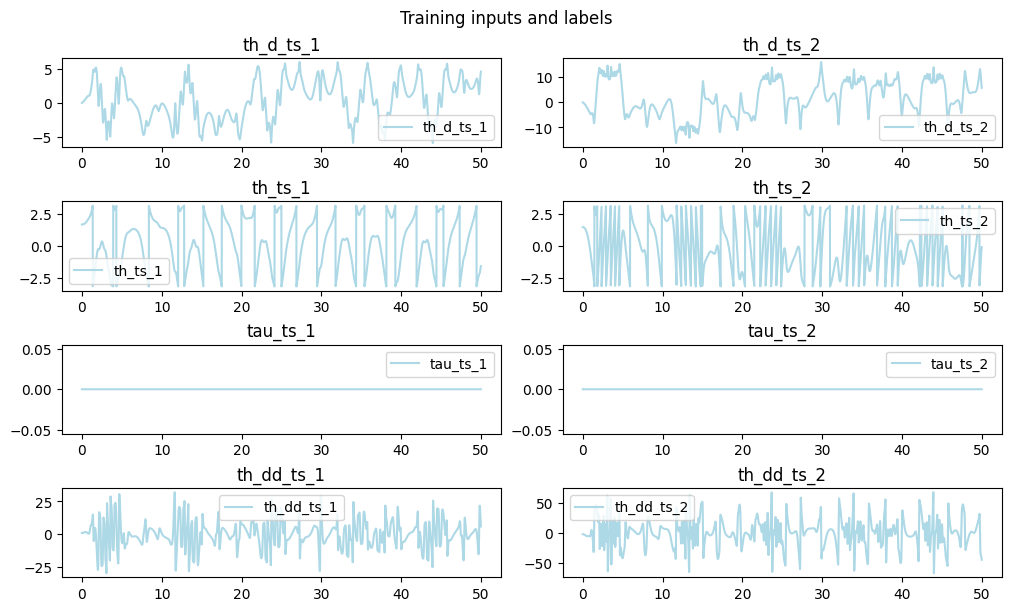

In [6]:
# load data generated in task 3c
dataset_name_big_osc = "trajectory_zero_gains_big_osc"
df_big_osc = pd.read_csv(datasets_dir / f"{dataset_name_big_osc}.csv")

# indicate input X and Y labels training data
input_columns = ["th_d_ts_1", "th_d_ts_2", "th_ts_1", "th_ts_2", "tau_ts_1", "tau_ts_2"]
output_columns = ["th_dd_ts_1", "th_dd_ts_2"]

# plot the training dataset
plot_data(
    df_big_osc,
    input_columns,
    output_columns,
    filepath=str(outputs_dir / f"task_3d-3_dataset_plot_{dataset_name_big_osc}.pdf"),
)

# generate torch tensors for training
X_big_osc, Y_big_osc = generate_training_data(df_big_osc, input_columns, output_columns)

### Task 3d.3.2 - Train the GP model (0.5p)
Initialize the ForwardDynamicsModel and **train it** using the dataset previously loaded.

  0%|          | 0/30 [00:00<?, ?it/s]

/tmp/ipykernel_5579/2178743684.py:63: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  self.elbo_loss_vec[i] = loss_dataset


Training finished with the following statistics.
Lengthscale:
 tensor([[7.7341, 7.1021, 0.7993, 0.8621, 0.6931, 0.6931]], dtype=torch.float64)
Outputscale:
 tensor([2.2956, 2.6907], dtype=torch.float64)
ELBO:
 tensor(-16.2937, dtype=torch.float64)


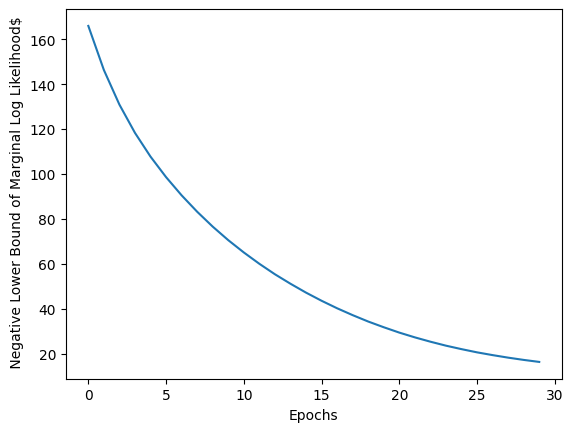

In [7]:
# set random seed
torch.manual_seed(42)

forward_model_big_osc = ForwardDynamicsModel(X_big_osc, Y_big_osc)
# YOUR CODE to train the gp
forward_model_big_osc.train()

# print model info
forward_model_big_osc.print_info()

# plot convergence of training loss
forward_model_big_osc.plot_convergence(dataset_name_big_osc)


### Task 3d.3.3 - Visualize the learned dynamics with a phase portrait (0.5p)
For more information about phase portraits, please consult the [Wikipedia article](https://en.wikipedia.org/wiki/Phase_portrait).

Since we cannot visualize the phase portrait of a double pendulum in 2D (it works for a standard pendulum, though), we are going to lock the second DoF by considering the configuration and its velocity equal to the one of the first joint, i.e., no relative movement. We are studying the unforced dynamics of the systems. Hence, the external torques (for both joints) are set to zero. 

Define `tau1`and `tau2` used for plotting correctly.

In [8]:
theta_dot_min, theta_dot_max = (-8, 8)

# Create a grid of input points for prediction
theta_range = np.linspace(-np.pi, np.pi, 100)
theta_dot_range = np.linspace(theta_dot_min, theta_dot_max, 100)

theta_grid, theta_dot_grid = np.meshgrid(theta_range, theta_dot_range)

# Set torques to zero
tau1 = np.zeros_like(theta_grid)
tau2 = np.zeros_like(theta_grid)

# Create input points
input_points = np.column_stack(
    (
        theta_dot_grid.flatten(),
        theta_dot_grid.flatten(),
        theta_grid.flatten(),
        theta_grid.flatten(),
        tau1.flatten(),
        tau2.flatten(),
    )
)

X_test = torch.tensor(input_points, dtype=torch.float32)

### Task 3d.3.4 - Predict mean and standard deviation of each of the outputs using the learned model (1p)

In [17]:
# Model prediction on X_test
forward_model_big_osc.gp.eval()
forward_model_big_osc.likelihood.eval()
with torch.no_grad(), gpytorch.settings.fast_pred_var():
    predictions = forward_model_big_osc.likelihood(forward_model_big_osc.predict(X_test))
    Y_pred_mean = predictions.mean
    Y_pred_std = predictions.stddev

# print(forward_model_big_osc.predict(X_test))

Y_pred_mean_grid_big_osc = Y_pred_mean[:, 0].view(100, 100).detach().cpu().numpy()
Y_pred_std_grid_big_osc = Y_pred_std[:, 0].view(100, 100).detach().cpu().numpy()

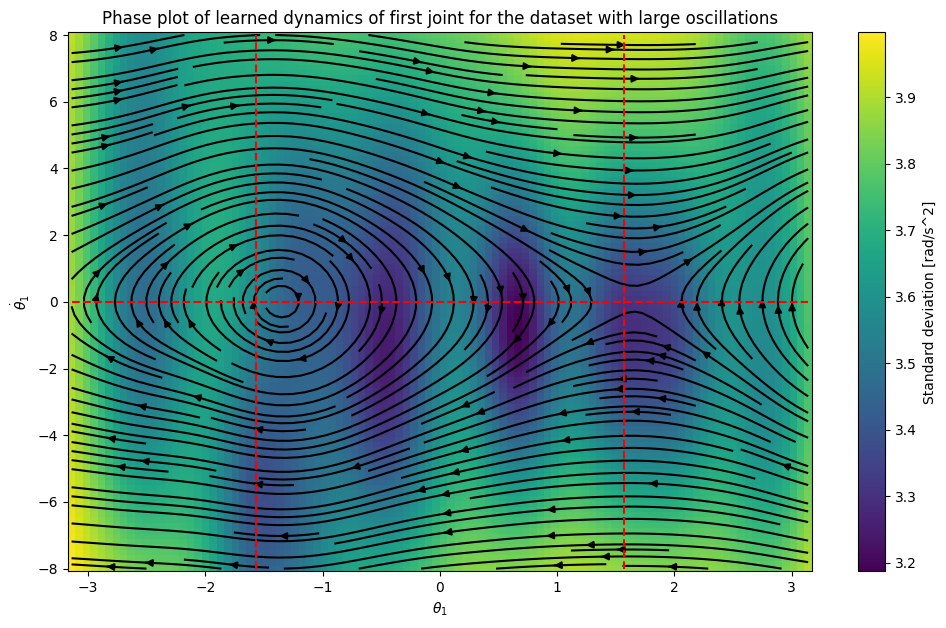

In [18]:
# Plotting the phase portrait
fig, ax = plt.subplots(figsize=(12, 7))

ax.streamplot(
    theta_grid,
    theta_dot_grid,
    theta_dot_grid,
    Y_pred_mean_grid_big_osc,
    density=2,
    color="black",
)
ax.vlines(-np.pi / 2, theta_dot_min, theta_dot_max, color="red", linestyles="dashed")
ax.vlines(np.pi / 2, theta_dot_min, theta_dot_max, color="red", linestyles="dashed")
ax.hlines(0, -np.pi, np.pi, color="red", linestyles="dashed")
cax = ax.pcolormesh(theta_grid, theta_dot_grid, Y_pred_std_grid_big_osc, cmap="viridis")
ax.set_xlabel(r"$\theta_1$")
ax.set_ylabel(r"$\dot{\theta}_1$")
ax.title.set_text(
    "Phase plot of learned dynamics of first joint for the dataset with large oscillations"
)
cbar = fig.colorbar(cax)
cbar.set_label("Standard deviation [rad/s^2]")
plt.savefig(str(outputs_dir / f"task_3d-3_phase_portrait_{dataset_name_big_osc}.pdf"))

## Task 3d.4 - Train a GP on the dataset with small oscillations and visualize phase portrait (1p)
### Task 3d.4.1 - Load the dataset with small oscillations and visualize it (0p)
Load the dataset generated by initializing the double pendulum close to the tip-down configuration (without any external torques applied).

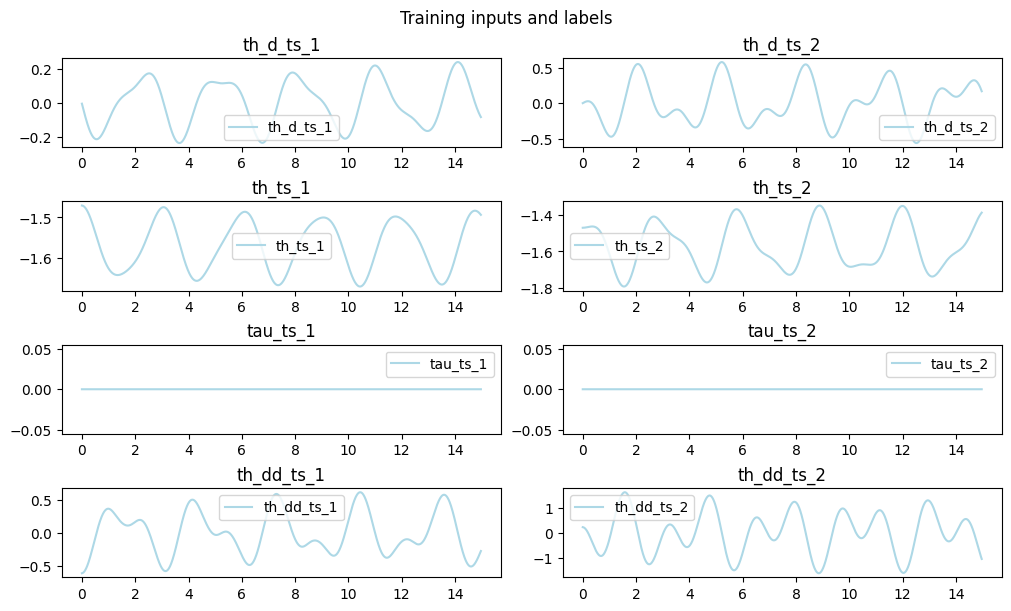

In [19]:
# load data generated in task 3c
dataset_name_small_osc = "trajectory_zero_gains_small_osc"
df_small_osc = pd.read_csv(datasets_dir / f"{dataset_name_small_osc}.csv")

# indicate input X and Y labels training data
input_columns = ["th_d_ts_1", "th_d_ts_2", "th_ts_1", "th_ts_2", "tau_ts_1", "tau_ts_2"]
output_columns = ["th_dd_ts_1", "th_dd_ts_2"]

# plot the GP training data
plot_data(
    df_small_osc,
    input_columns,
    output_columns,
    filepath=str(outputs_dir / f"task_3d-4_dataset_plot_{dataset_name_small_osc}.pdf"),
)

# generate torch tensors for training
X_small_osc, Y_small_osc = generate_training_data(
    df_small_osc, input_columns, output_columns
)

### Task 3d.4.2 - Train the Forward Dynamic model (0.5p)
Initialize the model and **train it** using the dataset previously loaded.

  0%|          | 0/30 [00:00<?, ?it/s]

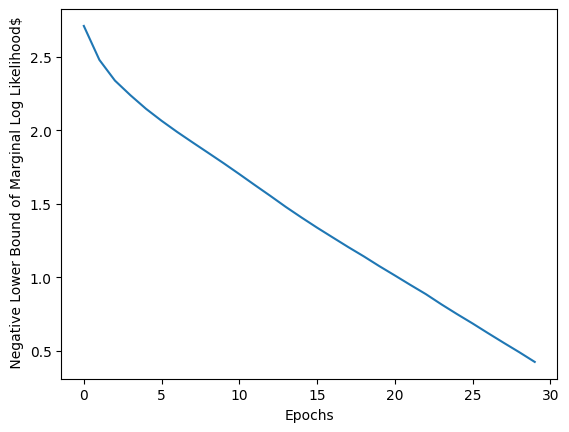

In [20]:
# set random seed
torch.manual_seed(42)

forward_model_small_osc = ForwardDynamicsModel(X_small_osc, Y_small_osc)
# YOUR CODE to train the gp
forward_model_small_osc.train()

# plot convergence of training loss
forward_model_small_osc.plot_convergence(dataset_name_small_osc)

### Task 3d.4.3 - Visualize the learned dynamics with a phase portrait (0.5p)

In [21]:
# Model prediction on X_test
forward_model_small_osc.gp.eval()
forward_model_small_osc.likelihood.eval()
with torch.no_grad(), gpytorch.settings.fast_pred_var():
    predictions = forward_model_small_osc.likelihood(forward_model_small_osc.predict(X_test))
    Y_pred_mean = predictions.mean
    Y_pred_std = predictions.stddev

Y_pred_mean_grid_small_osc = Y_pred_mean[:, 0].view(100, 100).detach().cpu().numpy()
Y_pred_std_grid_small_osc = Y_pred_std[:, 0].view(100, 100).detach().cpu().numpy()

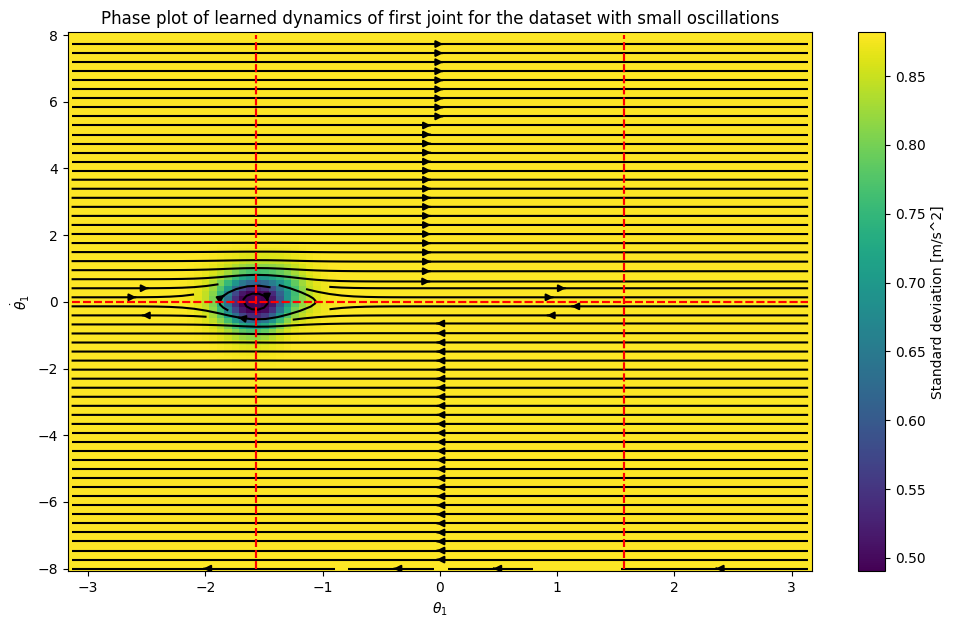

In [22]:
# Plotting
fig, ax = plt.subplots(figsize=(12, 7))

ax.streamplot(
    theta_grid,
    theta_dot_grid,
    theta_dot_grid,
    Y_pred_mean_grid_small_osc,
    density=2,
    color="black",
)
ax.vlines(-np.pi / 2, theta_dot_min, theta_dot_max, color="red", linestyles="dashed")
ax.vlines(np.pi / 2, theta_dot_min, theta_dot_max, color="red", linestyles="dashed")
ax.hlines(0, -np.pi, np.pi, color="red", linestyles="dashed")
cax = ax.pcolormesh(
    theta_grid, theta_dot_grid, Y_pred_std_grid_small_osc, cmap="viridis"
)
ax.vlines(-np.pi / 2, theta_dot_min, theta_dot_max, color="red", linestyles="dashed")
ax.vlines(np.pi / 2, theta_dot_min, theta_dot_max, color="red", linestyles="dashed")
ax.hlines(0, -np.pi, np.pi, color="red", linestyles="dashed")
ax.set_xlabel(r"$\theta_1$")
ax.set_ylabel(r"$\dot{\theta}_1$")
ax.title.set_text(
    "Phase plot of learned dynamics of first joint for the dataset with small oscillations"
)
cbar = fig.colorbar(cax)
cbar.set_label("Standard deviation [m/s^2]")
plt.savefig(str(outputs_dir / f"task_3d-4_phase_portrait_{dataset_name_small_osc}.pdf"))

## Task 3d.5 - Comparison of phase portraits (3p)
Compare the two-phase portraits. In particular, explain why the colors and the vector field are different on the right side of the phase plot. Why there are horizontal lines on the right side of the second phase plot and not on the first one? Why is the streamplot prediction exactly horizontal there? and not, for example, vertical? 

 Write your answer below. 

- why the colors and the vector field are different on the right side of the phase plot?


  The two phase portraits differ because they were trained on wildly different training datas. The first one was trained with a double pendulum initialized in the up-right position (unstable), leading to a diverse dataset where the GP has training data across the entire phase space, learning a meaningful vector everywhere (exhibits low uncertainty of std 3.2 - 3.9 rad/s^2 across the entire plot). We also see closed orbits around the stable equilibrium (pendulum down) and a saddle point around the unstable one (pendulum up). The second one was trained with a double pendulum intitialized in the bottom positon (stable equilibrium), leading to very little variation in the training data, and thus the GP cannot meaningfully cover the entire phase space. In the latter, the pendulum visited only a small portion of the neighborhood around the stable equilibrium, and the GP is incapable of generalizing outside of it: hence there is low uncertainty around $\theta_1 = -\pi / 2$, $\dot\theta_1 = 0$, and very high everywhere else.
  
- Why there are horizontal lines on the right side of the second phase plot and not on the first one? Why is the streamplot prediction exactly horizontal there? and not, for example, vertical?


  In the second phase plot, for unseen regions (far from equilibrium), the GP predicts zero mean prior, so the vector reduces to $(\dot\theta_1, 0)$ everywhere. Since the angular velocity is different from 0 everywhere except the dahsed horizontal red line, this vector is purley horizontal. This is not the case for the first GP because the training data covers well the entire distribution of the phase plot, and the GP is able to accurately model the vectors. The lines are not vertical because that would require for the angular velocity to be 0 and for the angular acceleration to be different from zero simultaneously, which is not the case here.